# Day 4: Fund Performance Analytics

## Objective

The objective of this notebook is to evaluate the performance of mutual funds using various financial metrics such as annual returns, CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, and Maximum Drawdown.

The analysis also compares fund performance with benchmark indices and ranks funds based on multiple performance indicators to identify the best and worst performing schemes.

In [92]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
plt.style.use("ggplot")

In [93]:
# Load all required datasets

fund_master = pd.read_csv("../data/processed/01_fund_master.csv")
nav_history = pd.read_csv("../data/processed/02_nav_history.csv")
scheme_performance = pd.read_csv("../data/processed/07_scheme_performance.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

In [94]:
print("Fund Master:", fund_master.shape)
print("NAV History:", nav_history.shape)
print("Scheme Performance:", scheme_performance.shape)
print("Benchmark:", benchmark.shape)

Fund Master: (40, 15)
NAV History: (46000, 3)
Scheme Performance: (40, 19)
Benchmark: (8050, 3)


In [95]:
nav_history.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [96]:
# Convert date column to datetime
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Sort by fund and date
nav_history = nav_history.sort_values(["amfi_code", "date"])

# Calculate daily return for each fund
nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"].pct_change()
)

# View first few rows
nav_history.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [97]:
# Check summary statistics of daily returns
nav_history["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [98]:
# Count missing values in daily_return
nav_history["daily_return"].isna().sum()

np.int64(40)

In [99]:
# Save the daily returns file
nav_history.to_csv(
    "../outputs/returns_computed.csv",
    index=False
)

print("returns_computed.csv saved successfully!")

returns_computed.csv saved successfully!


In [100]:
# Check the date range in NAV history
print(nav_history["date"].min())
print(nav_history["date"].max())

2022-01-03 00:00:00
2026-05-29 00:00:00


In [101]:
print(nav_history["amfi_code"].nunique())

40


In [102]:
# Calculate CAGR for each mutual fund

cagr_results = []

for fund in nav_history["amfi_code"].unique():

    df = nav_history[nav_history["amfi_code"] == fund].sort_values("date")

    start_nav = df.iloc[0]["nav"]
    end_nav = df.iloc[-1]["nav"]

    start_date = df.iloc[0]["date"]
    end_date = df.iloc[-1]["date"]

    years = (end_date - start_date).days / 365.25

    cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

    cagr_results.append({
        "amfi_code": fund,
        "start_date": start_date,
        "end_date": end_date,
        "years": round(years, 2),
        "CAGR (%)": round(cagr, 2)
    })

cagr_df = pd.DataFrame(cagr_results)

cagr_df.head()

,amfi_code,start_date,end_date,years,CAGR (%)
0,100016,2022-01-03,2026-05-29,4.4,2.64
1,100025,2022-01-03,2026-05-29,4.4,4.46
2,100033,2022-01-03,2026-05-29,4.4,30.12
3,101206,2022-01-03,2026-05-29,4.4,23.54
4,101207,2022-01-03,2026-05-29,4.4,7.94


In [103]:
cagr_df.to_csv("../outputs/cagr_report.csv", index=False)

print("cagr_report.csv saved successfully!")

cagr_report.csv saved successfully!


In [104]:
# Annual risk-free rate (6.5%)
risk_free_rate = 0.065

sharpe_results = []

for fund in nav_history["amfi_code"].unique():

    df = nav_history[nav_history["amfi_code"] == fund]

    returns = df["daily_return"].dropna()

    if len(returns) > 0:

        annual_return = returns.mean() * 252
        annual_volatility = returns.std() * np.sqrt(252)

        sharpe = (annual_return - risk_free_rate) / annual_volatility

        sharpe_results.append({
            "amfi_code": fund,
            "Annual Return": round(annual_return * 100, 2),
            "Annual Volatility": round(annual_volatility * 100, 2),
            "Sharpe Ratio": round(sharpe, 2)
        })

sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df.head()

,amfi_code,Annual Return,Annual Volatility,Sharpe Ratio
0,100016,3.57,14.55,-0.20
1,100025,4.29,3.91,-0.57
2,100033,27.21,18.94,1.09
3,101206,21.46,14.57,1.03
4,101207,10.70,25.80,0.16


In [105]:
sharpe_df.to_csv("../outputs/sharpe_values.csv", index=False)

print("sharpe_values.csv saved successfully!")

sharpe_values.csv saved successfully!


In [106]:
# Annual risk-free rate
risk_free_rate = 0.065

sortino_results = []

for fund in nav_history["amfi_code"].unique():

    df = nav_history[nav_history["amfi_code"] == fund]

    returns = df["daily_return"].dropna()

    if len(returns) > 0:

        annual_return = returns.mean() * 252

        # Downside returns only
        downside_returns = returns[returns < 0]

        if len(downside_returns) > 0:

            downside_std = downside_returns.std() * np.sqrt(252)

            sortino = (annual_return - risk_free_rate) / downside_std

        else:
            sortino = np.nan

        sortino_results.append({
            "amfi_code": fund,
            "Annual Return": round(annual_return * 100, 2),
            "Downside Volatility": round(downside_std * 100, 2),
            "Sortino Ratio": round(sortino, 2)
        })

sortino_df = pd.DataFrame(sortino_results)

sortino_df.head()

,amfi_code,Annual Return,Downside Volatility,Sortino Ratio
0,100016,3.57,8.35,-0.35
1,100025,4.29,2.35,-0.94
2,100033,27.21,11.32,1.83
3,101206,21.46,8.32,1.80
4,101207,10.70,15.17,0.28


In [107]:
sortino_df.to_csv("../outputs/sortino_values.csv", index=False)

print("sortino_values.csv saved successfully!")

sortino_values.csv saved successfully!


In [108]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [109]:
# Convert date column to datetime
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Sort data
benchmark = benchmark.sort_values(["index_name", "date"])

# Calculate benchmark daily returns
benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
    .pct_change()
)

# Display first 10 rows
benchmark.head(10)

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726
3455,2022-01-10,BSE_SMALLCAP,26476.06,0.006049
3456,2022-01-11,BSE_SMALLCAP,26462.96,-0.000495
3457,2022-01-12,BSE_SMALLCAP,26090.99,-0.014056
3458,2022-01-13,BSE_SMALLCAP,26085.36,-0.000216
3459,2022-01-14,BSE_SMALLCAP,26081.45,-0.000150


In [110]:
# Convert date column to datetime
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Sort data
benchmark = benchmark.sort_values(["index_name", "date"])

# Calculate benchmark daily returns
benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
    .pct_change()
)

# Display first 10 rows
benchmark.head(10)

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726
3455,2022-01-10,BSE_SMALLCAP,26476.06,0.006049
3456,2022-01-11,BSE_SMALLCAP,26462.96,-0.000495
3457,2022-01-12,BSE_SMALLCAP,26090.99,-0.014056
3458,2022-01-13,BSE_SMALLCAP,26085.36,-0.000216
3459,2022-01-14,BSE_SMALLCAP,26081.45,-0.000150


In [111]:
# Merge fund returns with benchmark returns using date

merged_data = pd.merge(
    nav_history,
    benchmark[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

# Remove missing values
merged_data = merged_data.dropna(subset=["daily_return", "benchmark_return"])

print(merged_data.head())

    amfi_code       date       nav  daily_return  benchmark_return
7      100016 2022-01-04  515.0971     -0.010306          0.019783
8      100016 2022-01-04  515.0971     -0.010306          0.001516
9      100016 2022-01-04  515.0971     -0.010306          0.000044
10     100016 2022-01-04  515.0971     -0.010306         -0.013540
11     100016 2022-01-04  515.0971     -0.010306          0.011253


In [112]:
print(merged_data.shape)

(321720, 5)


In [113]:
alpha_beta_results = []

for fund in merged_data["amfi_code"].unique():

    fund_data = merged_data[merged_data["amfi_code"] == fund]

    if len(fund_data) > 30:

        slope, intercept, r_value, p_value, std_err = stats.linregress(
            fund_data["benchmark_return"],
            fund_data["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta_results.append({
            "amfi_code": fund,
            "Alpha": round(alpha, 4),
            "Beta": round(beta, 4)
        })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

alpha_beta_df.head()

,amfi_code,Alpha,Beta
0,100016,0.0350,0.0048
1,100025,0.0433,-0.0034
2,100033,0.2688,0.0241
3,101206,0.2147,-0.0001
4,101207,0.1102,-0.0236


In [114]:
alpha_beta_df.to_csv("../outputs/alpha_beta.csv", index=False)

print("alpha_beta.csv saved successfully!")

alpha_beta.csv saved successfully!


In [115]:
max_dd_results = []

for fund in nav_history["amfi_code"].unique():

    df = nav_history[nav_history["amfi_code"] == fund].copy()

    df = df.sort_values("date")

    # Running maximum NAV
    df["running_max"] = df["nav"].cummax()

    # Drawdown
    df["drawdown"] = (df["nav"] / df["running_max"]) - 1

    # Maximum drawdown
    max_dd = df["drawdown"].min()

    max_dd_results.append({
        "amfi_code": fund,
        "Maximum Drawdown (%)": round(max_dd * 100, 2)
    })

max_dd_df = pd.DataFrame(max_dd_results)

max_dd_df.head()

,amfi_code,Maximum Drawdown (%)
0,100016,-24.73
1,100025,-4.31
2,100033,-16.22
3,101206,-11.29
4,101207,-35.45


In [116]:
max_dd_df.to_csv("../outputs/max_drawdown.csv", index=False)

print("max_drawdown.csv saved successfully!")

max_drawdown.csv saved successfully!


In [117]:
fund_scorecard = (
    cagr_df[["amfi_code", "CAGR (%)"]]
    .merge(sharpe_df[["amfi_code", "Sharpe Ratio"]], on="amfi_code")
    .merge(sortino_df[["amfi_code", "Sortino Ratio"]], on="amfi_code")
    .merge(alpha_beta_df, on="amfi_code")
    .merge(max_dd_df, on="amfi_code")
)

fund_scorecard.head()

,amfi_code,CAGR (%),Sharpe Ratio,Sortino Ratio,Alpha,Beta,Maximum Drawdown (%)
0,100016,2.64,-0.20,-0.35,0.0350,0.0048,-24.73
1,100025,4.46,-0.57,-0.94,0.0433,-0.0034,-4.31
2,100033,30.12,1.09,1.83,0.2688,0.0241,-16.22
3,101206,23.54,1.03,1.80,0.2147,-0.0001,-11.29
4,101207,7.94,0.16,0.28,0.1102,-0.0236,-35.45


In [118]:
fund_scorecard.to_csv("../outputs/fund_scorecard.csv", index=False)

print("fund_scorecard.csv saved successfully!")

fund_scorecard.csv saved successfully!


In [119]:
# Rank funds based on CAGR

ranked_funds = fund_scorecard.sort_values(
    by="CAGR (%)",
    ascending=False
)

ranked_funds.head(10)

,amfi_code,CAGR (%),Sharpe Ratio,Sortino Ratio,Alpha,Beta,Maximum Drawdown (%)
25,120505,32.83,1.18,2.03,0.2951,-0.0175,-18.19
21,119598,32.42,0.95,1.68,0.3031,-0.0035,-28.71
39,149324,32.29,0.95,1.62,0.2958,0.0367,-31.17
36,148569,31.95,1.23,2.15,0.2808,0.0176,-16.40
34,148567,30.97,1.45,2.39,0.2691,0.0105,-11.27
30,120843,30.91,1.31,2.36,0.2732,-0.0044,-12.97
2,100033,30.12,1.09,1.83,0.2688,0.0241,-16.22
38,149323,29.58,1.13,1.88,0.2657,0.0013,-17.25
16,119094,28.21,1.00,1.70,0.2627,-0.0287,-20.96
19,119551,25.80,1.21,2.14,0.2345,-0.0252,-15.01


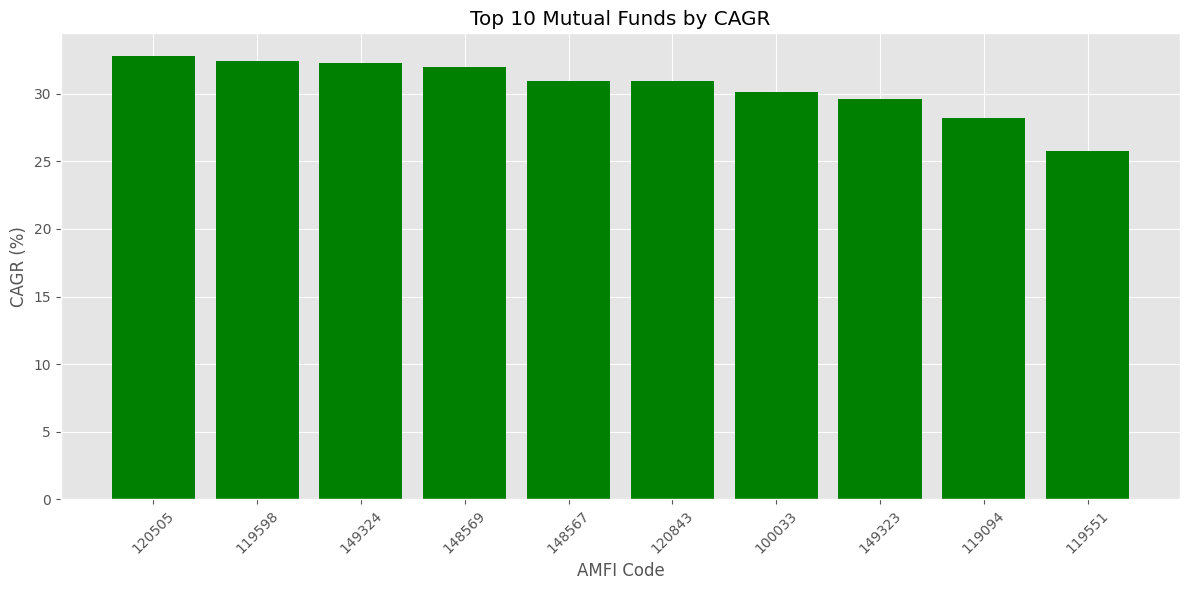

In [120]:
plt.figure(figsize=(12,6))

plt.bar(
    ranked_funds["amfi_code"].astype(str).head(10),
    ranked_funds["CAGR (%)"].head(10),
    color="green"
)

plt.title("Top 10 Mutual Funds by CAGR")
plt.xlabel("AMFI Code")
plt.ylabel("CAGR (%)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../outputs/charts/top10_cagr.png")

plt.show()

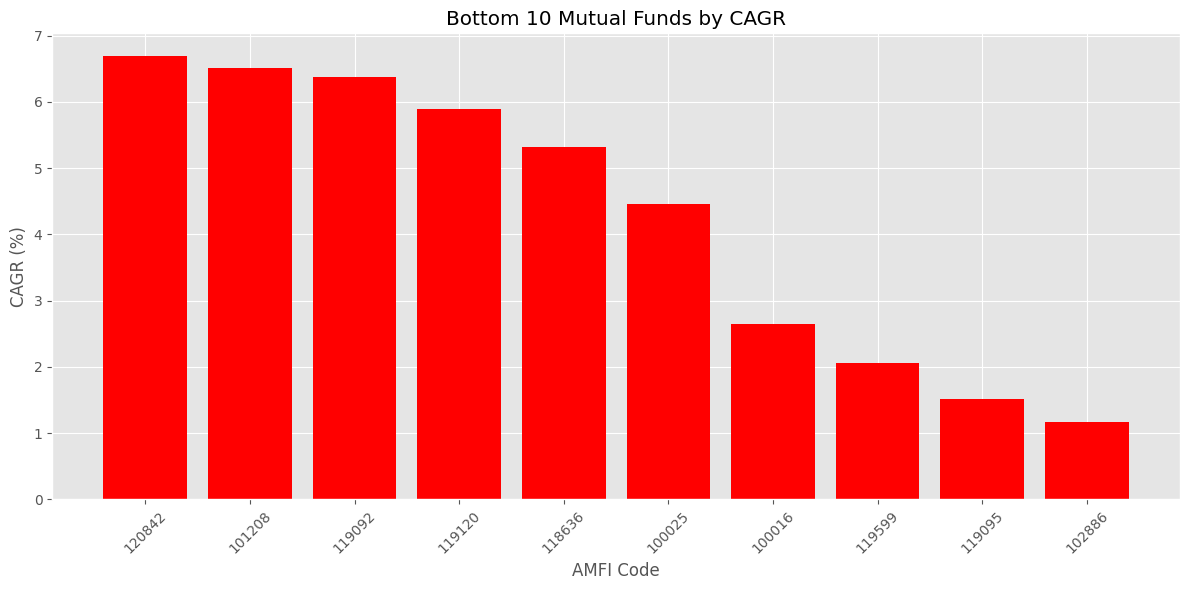

In [121]:
bottom_funds = ranked_funds.tail(10)

plt.figure(figsize=(12,6))

plt.bar(
    bottom_funds["amfi_code"].astype(str),
    bottom_funds["CAGR (%)"],
    color="red"
)

plt.title("Bottom 10 Mutual Funds by CAGR")
plt.xlabel("AMFI Code")
plt.ylabel("CAGR (%)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../outputs/charts/bottom10_cagr.png")

plt.show()

In [122]:
# Merge fund information with performance scorecard

final_report = fund_master.merge(
    fund_scorecard,
    on="amfi_code",
    how="inner"
)

final_report.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,...,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code,CAGR (%),Sharpe Ratio,Sortino Ratio,Alpha,Beta,Maximum Drawdown (%)
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,...,1000,Sohini Andani,Moderate,EC01,25.80,1.21,2.14,0.2345,-0.0252,-15.01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,...,1000,Sohini Andani,Moderate,EC01,21.52,0.95,1.61,0.2005,-0.0186,-11.80
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,...,1000,R. Srinivasan,Very High,EC03,32.42,0.95,1.68,0.3031,-0.0035,-28.71
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,...,1000,R. Srinivasan,Very High,EC03,2.05,-0.06,-0.09,0.0493,0.0101,-52.57
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,...,1000,Dinesh Ahuja,Low,DC02,5.89,-0.23,-0.38,0.0561,-0.0004,-4.33


In [123]:
print(final_report.shape)

final_report.info()

(40, 21)
<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   amfi_code             40 non-null     int64  
 1   fund_house            40 non-null     str    
 2   scheme_name           40 non-null     str    
 3   category              40 non-null     str    
 4   sub_category          40 non-null     str    
 5   plan                  40 non-null     str    
 6   launch_date           40 non-null     str    
 7   benchmark             40 non-null     str    
 8   expense_ratio_pct     40 non-null     float64
 9   exit_load_pct         40 non-null     float64
 10  min_sip_amount        40 non-null     int64  
 11  min_lumpsum_amount    40 non-null     int64  
 12  fund_manager          40 non-null     str    
 13  risk_category         40 non-null     str    
 14  sebi_category_code    40 non-null     str    
 15  CAGR (%)              40 no

In [124]:
final_report.to_csv(
    "../outputs/final_mutual_fund_report.csv",
    index=False
)

print("Final Mutual Fund Report Saved Successfully!")

Final Mutual Fund Report Saved Successfully!


In [125]:
category_performance = (
    final_report
    .groupby("category")["CAGR (%)"]
    .mean()
    .sort_values(ascending=False)
)

category_performance

category
Equity    18.620000
Debt       6.056667
Name: CAGR (%), dtype: float64

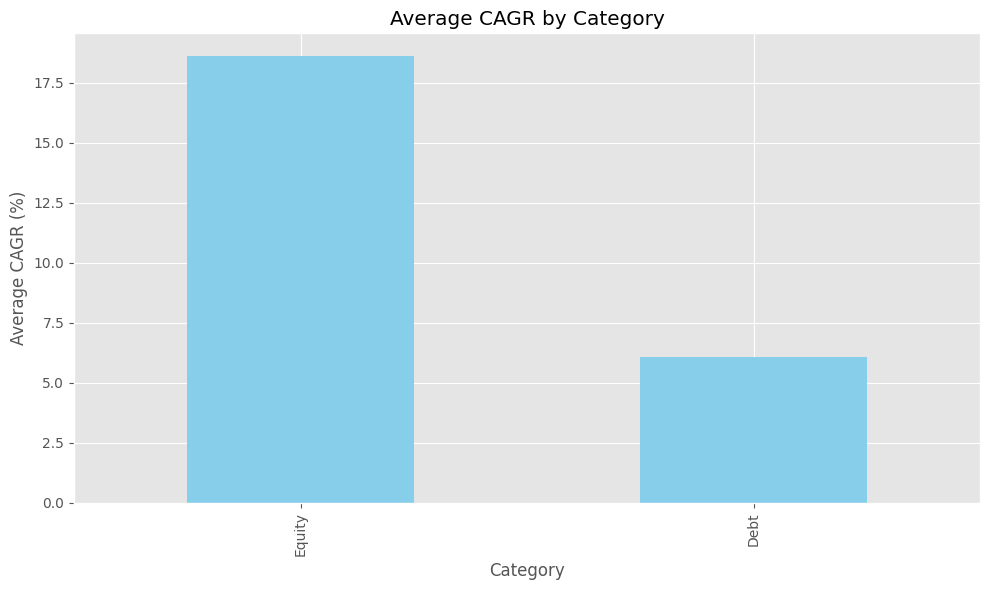

In [126]:
plt.figure(figsize=(10,6))

category_performance.plot(
    kind="bar",
    color="skyblue"
)

plt.title("Average CAGR by Category")
plt.xlabel("Category")
plt.ylabel("Average CAGR (%)")

plt.tight_layout()

plt.savefig("../outputs/charts/category_cagr.png")

plt.show()

In [127]:
risk_analysis = (
    final_report
    .groupby("risk_category")["Sharpe Ratio"]
    .mean()
)

risk_analysis

risk_category
High               0.725000
Low               -0.261667
Moderate           0.710625
Moderately High    0.877500
Very High          0.395000
Name: Sharpe Ratio, dtype: float64

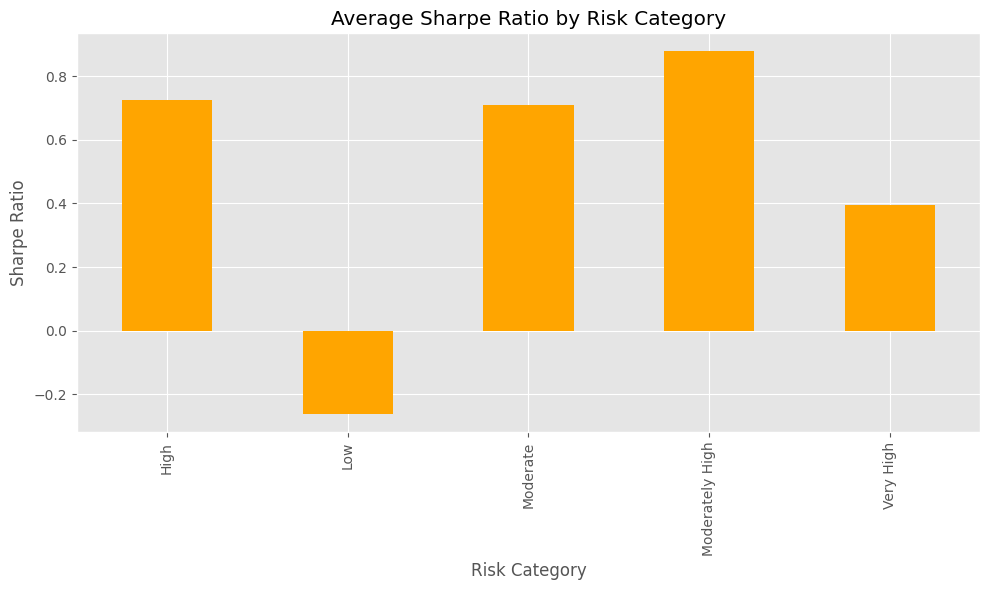

In [128]:
plt.figure(figsize=(10,6))

risk_analysis.plot(
    kind="bar",
    color="orange"
)

plt.title("Average Sharpe Ratio by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Sharpe Ratio")

plt.tight_layout()

plt.savefig("../outputs/charts/risk_sharpe.png")

plt.show()

In [129]:
top5 = final_report.sort_values(
    "CAGR (%)",
    ascending=False
).head(5)

top5

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,...,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code,CAGR (%),Sharpe Ratio,Sortino Ratio,Alpha,Beta,Maximum Drawdown (%)
12,120505,ICICI Prudential MF,ICICI Pru Midcap Fund - Regular - Growth,Equity,Mid Cap,Regular,2004-10-28,NIFTY Midcap 150 TRI,1.36,1.0,...,1000,Sankaran Naren,High,EC02,32.83,1.18,2.03,0.2951,-0.0175,-18.19
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,...,1000,R. Srinivasan,Very High,EC03,32.42,0.95,1.68,0.3031,-0.0035,-28.71
39,149324,DSP Mutual Fund,DSP Small Cap Fund - Regular - Growth,Equity,Small Cap,Regular,2007-06-14,BSE 250 SmallCap TRI,1.52,1.0,...,1000,Vinit Sambre,Very High,EC03,32.29,0.95,1.62,0.2958,0.0367,-31.17
36,148569,Mirae Asset MF,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,ELSS,Regular,2015-12-28,NIFTY 500 TRI,1.60,1.0,...,1000,Neelesh Surana,High,EC05,31.95,1.23,2.15,0.2808,0.0176,-16.40
34,148567,Mirae Asset MF,Mirae Asset Large Cap Fund - Regular - Growth,Equity,Large Cap,Regular,2008-04-04,NIFTY 100 TRI,1.46,1.0,...,1000,Gaurav Misra,Moderate,EC01,30.97,1.45,2.39,0.2691,0.0105,-11.27


In [130]:
top5.to_csv(
    "../outputs/top5_funds.csv",
    index=False
)

print("Top 5 funds saved!")

Top 5 funds saved!


In [131]:
# Top 5 funds based on CAGR

top5_codes = top5["amfi_code"].tolist()

top5_data = nav_history[
    nav_history["amfi_code"].isin(top5_codes)
].copy()

top5_data.head()

,amfi_code,date,nav,daily_return
2300,119598,2022-01-03,89.8738,NaN
2301,119598,2022-01-04,88.5495,-0.014735
2302,119598,2022-01-05,88.0925,-0.005161
2303,119598,2022-01-06,88.5175,0.004824
2304,119598,2022-01-07,91.4235,0.032830


In [132]:
# Get benchmark names for Top 5 funds

top5_info = final_report[
    final_report["amfi_code"].isin(top5_codes)
][["amfi_code", "scheme_name", "benchmark"]]

top5_info

,amfi_code,scheme_name,benchmark
2,119598,SBI Small Cap Fund - Regular Plan - Growth,BSE 250 SmallCap TRI
12,120505,ICICI Pru Midcap Fund - Regular - Growth,NIFTY Midcap 150 TRI
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY 100 TRI
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,NIFTY 500 TRI
39,149324,DSP Small Cap Fund - Regular - Growth,BSE 250 SmallCap TRI


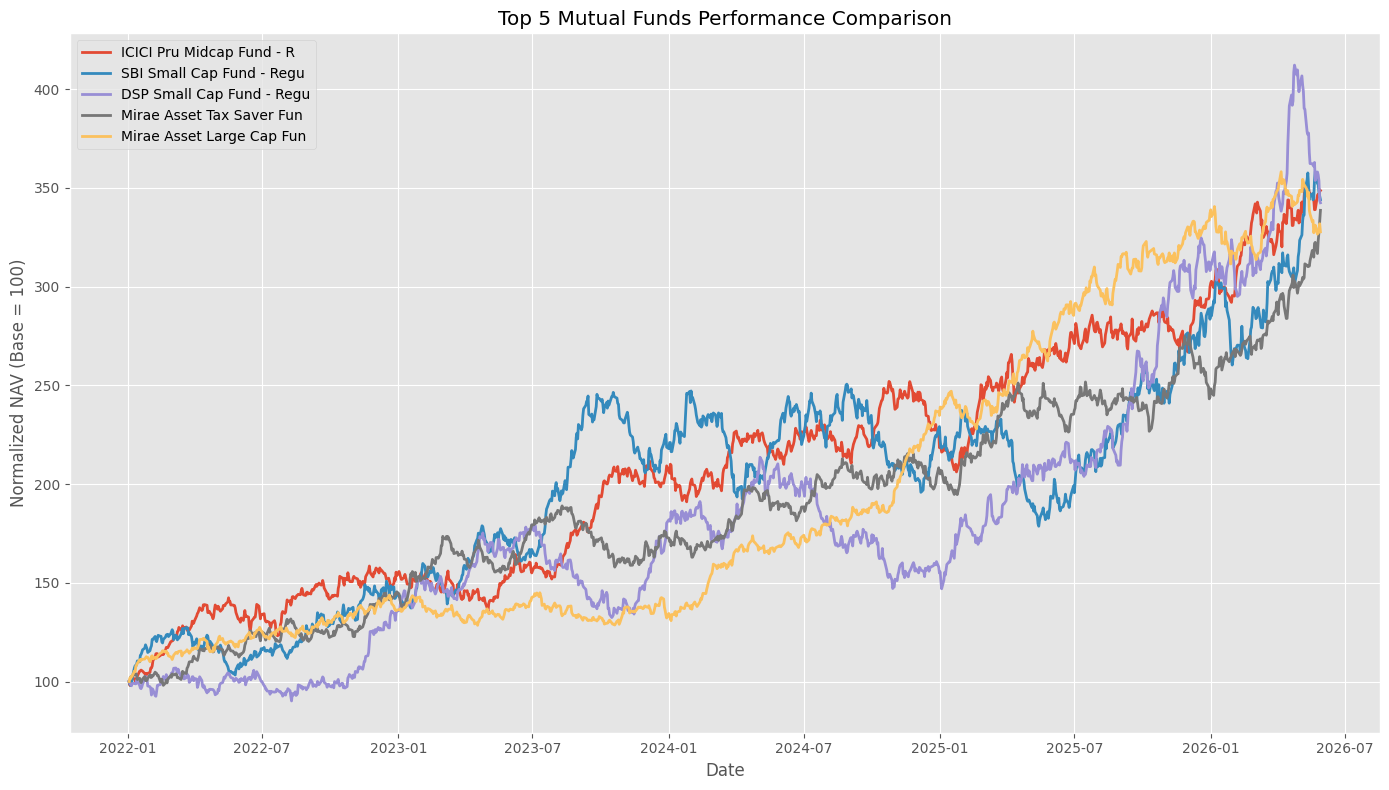

In [133]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

# Plot Top 5 Fund NAVs (Normalized)

for code in top5_codes:

    df = top5_data[top5_data["amfi_code"] == code].copy()

    df = df.sort_values("date")

    df["normalized_nav"] = (
        df["nav"] / df["nav"].iloc[0]
    ) * 100

    scheme = top5_info.loc[
        top5_info["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    plt.plot(
        df["date"],
        df["normalized_nav"],
        linewidth=2,
        label=scheme[:25]
    )

plt.title("Top 5 Mutual Funds Performance Comparison")
plt.xlabel("Date")
plt.ylabel("Normalized NAV (Base = 100)")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig("../outputs/charts/benchmark_comparison_chart.png")

plt.show()